# Set-Up

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.patches import ConnectionPatch

In [17]:
def voigt_profile_single(x, A1, centre1, gamma1, sigma1, offset):
    return(A1*voigt_profile(x - centre1, sigma1, gamma1) + offset)

def voigt_model_double(x, A1, center1, gamma1, sigma1,
                       A2, delta, gamma2, sigma2, offset):

    return (
        A1 * voigt_profile(x - center1, sigma1, gamma1) +
        A2 * voigt_profile(x - (center1 + delta), sigma2, gamma2) +
        offset
    )

def lorentzian_profile(x, gamma):
    return gamma / (np.pi * (x**2 + gamma**2))

def lorentzian_single_model(x, A, center, gamma, offset):
    return A*lorentzian_profile(x- center, gamma) + offset


def lorentzian_model_double(x, A1, center1, gamma1,
                            A2, delta, gamma2, offset):

    return (
        A1 * lorentzian_profile(x - center1, gamma1) +
        A2 * lorentzian_profile(x - (center1 + delta), gamma2) +
        offset
    )

def gaussian_profile(x, sigma):
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x**2)/(2*sigma**2))

def gaussian_single_model(x, A, center, sigma, offset):
    return A * gaussian_profile(x - center, sigma) + offset

def gaussian_model_double(x, A1, center1, sigma1,
                          A2, delta, sigma2, offset):

    return (
        A1 * gaussian_profile(x - center1, sigma1) +
        A2 * gaussian_profile(x - (center1 + delta), sigma2) +
        offset
    )

In [18]:
### Ocean

data_ocean = np.load("ocean_spectra_data.npz")

x_77_ocean = data_ocean["x_77"]
y_77_ocean = data_ocean["y_77"]
res_77_ocean = data_ocean["res_77"]

x_298_ocean = data_ocean["x_298"]
y_298_ocean = data_ocean["y_298"]
res_298_ocean = data_ocean["res_298"]

y_err_77_ocean = np.max(y_77_ocean) * 0.01
y_err_298_ocean = np.max(y_298_ocean) * 0.01

pop_77_ocean = data_ocean["pop_77"]
pop_298_ocean = data_ocean["pop_298"]

x_77_broad_ocean = data_ocean["x_77_broad"]
y_77_broad_ocean = data_ocean["y_77_broad"]

x_298_broad_ocean = data_ocean["x_298_broad"]
y_298_broad_ocean = data_ocean["y_298_broad"]

x_scalefactor_ocean = data_ocean["x_scalefactor"]
y_scalefactor_ocean = data_ocean["y_scalefactor"]


wavelength_range_ocean = np.linspace(x_77_broad_ocean[0], x_77_broad_ocean[-1], 1000)

#### Monochromator

data_mono = np.load("emission_9830_data.npz")

# 298K
x_298_mono = data_mono["x_293"]
y_298_mono = data_mono["y_293"]
err_298_mono = data_mono["err_293"]
residuals_298_mono = data_mono["residuals_293"]
pop_298_mono = data_mono["pop_293"]

# 77K
x_77_mono = data_mono["x_77"]
y_77_mono = data_mono["y_77"]
err_77_mono = data_mono["err_77"]
residuals_77_mono = data_mono["residuals_77"]
pop_77_mono = data_mono["pop_77"]

# Masks
left_298_mono = int(data_mono["left_293"])
right_298_mono = int(data_mono["right_293"])
left_77_mono = int(data_mono["left_77"])
right_77_mono = int(data_mono["right_77"])

# Scaling
scale_factor_mono = data_mono["scale_factor"]
x_scale_factor_mono = data_mono["x_scale_factor"]

R1_293_mono = pop_298_mono[1] + pop_298_mono[5]
R2_293_mono = pop_298_mono[1]

amp_R1_293 = voigt_model_double(np.array([R1_293_mono]), *pop_298_mono)[0]
amp_R2_293 = voigt_model_double(np.array([R2_293_mono]), *pop_298_mono)[0]

wavelength_range_mono = np.arange(x_298_mono[-1], x_298_mono[0], 0.1)

# Monochromator Plot

In [58]:
red_cb = "#e41a1c"
blue_cb = "#377eb8"

marker_293 = "^"
marker_77 = "v"

# R1 and R2 positions
R1_293_mono = pop_298_mono[1] + pop_298_mono[5]
R2_293_mono = pop_298_mono[1]

# R1 and R2 amplitudes
amp_R1_293_mono = voigt_model_double(np.array([R1_293_mono]), *pop_298_mono)[0]
amp_R2_293_mono = voigt_model_double(np.array([R2_293_mono]), *pop_298_mono)[0]

R1_77_mono = pop_77_mono[1] + pop_77_mono[5]
R2_77_mono = pop_77_mono[1]

amp_R1_77_mono = voigt_model_double(np.array([R1_77_mono]), *pop_77_mono)[0]
amp_R2_77_mono = voigt_model_double(np.array([R2_77_mono]), *pop_77_mono)[0]

pc_savepath_emission_spectra = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\emission_spectra.png"
laptop_savepath_emission_spectra = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\emission_spectra.png"

plt.rcParams.update({
    "font.size": 14,  # default text size
    "axes.titlesize": 16,  # title size
    "axes.labelsize": 15,  # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",  # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",  # Bold font in math
    "text.usetex": False
})

residual_band_298_mono = Patch(
    facecolor=red_cb,
    alpha=0.12,
    label=r"$298\,\mathrm{K}\, 1\sigma$ Residuals"
)

residual_band_77_mono = Patch(
    facecolor=blue_cb,
    alpha=0.12,
    label=r"$77\,\mathrm{K}\, 1\sigma$ Residuals"
)

legend_elements_mono = [
    Line2D([0], [0],
           color=red_cb,
           marker=marker_293,
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,

           label=r"$298\,\mathrm{K}$"),

    residual_band_298_mono,

    Line2D([0], [0],
           color=blue_cb,
           marker=marker_77,
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,
           label=r"$77\,\mathrm{K}$"),

    residual_band_77_mono
]

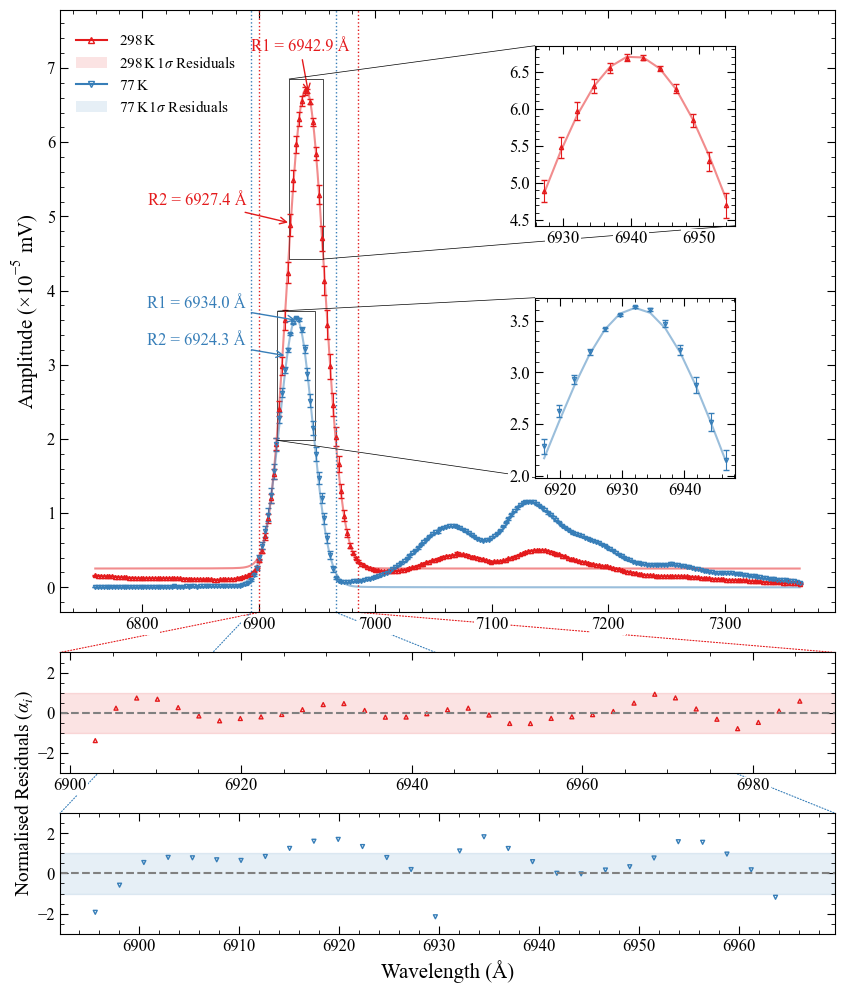

In [60]:
fig = plt.figure(figsize=(10, 12))

# Add extra spacing and larger residual panels
gs = fig.add_gridspec(
    5, 1,
    height_ratios=[6, 0.4, 1.2, 0.4, 1.2],  # spacer rows included
    hspace=0.0
)

ax_main = fig.add_subplot(gs[0])
ax_res1 = fig.add_subplot(gs[2])
ax_res2 = fig.add_subplot(gs[4])

# =====================
# Main spectrum
# =====================

scale_factor = 1e5
x_scale_factor = 10

marker_293 = "^"
marker_77 = "v"

data293 = ax_main.errorbar(
    x_298_mono * x_scale_factor, y_298_mono * scale_factor, yerr=err_298_mono * scale_factor,
    color=red_cb, capsize=2, fmt=marker_293, linestyle="none",
    markerfacecolor="none", markersize=3, elinewidth=0.8
)

data77 = ax_main.errorbar(
    x_77_mono * x_scale_factor, y_77_mono * scale_factor, yerr=err_77_mono * scale_factor,
    color=blue_cb, capsize=2, fmt=marker_77, linestyle="none",
    markerfacecolor="none", markersize=3, elinewidth=0.8
)

fit293, = ax_main.plot(
    wavelength_range_mono * x_scale_factor,
    voigt_model_double(wavelength_range_mono, *pop_298_mono) * scale_factor,
    color=red_cb, linestyle="-", alpha=0.5
)

fit77, = ax_main.plot(
    wavelength_range_mono * x_scale_factor,
    voigt_model_double(wavelength_range_mono, *pop_77_mono) * scale_factor,
    color=blue_cb, linestyle="-", alpha=0.5
)

# Get current limits
ymin, ymax = ax_main.get_ylim()

# Extend the top by, say, 10%
ax_main.set_ylim(ymin, ymax * 1.1)

# Mask boundaries
ax_main.axvline(x_298_mono[left_298_mono] * x_scale_factor, color=red_cb, linestyle=":", linewidth=1,
                label="293K Mask")
ax_main.axvline(x_298_mono[right_298_mono] * x_scale_factor, color=red_cb, linestyle=":", linewidth=1)
ax_main.axvline(x_77_mono[left_77_mono] * x_scale_factor, color=blue_cb, linestyle=":", linewidth=1,
                label="77K Mask")
ax_main.axvline(x_77_mono[right_77_mono] * x_scale_factor, color=blue_cb, linestyle=":", linewidth=1)

ax_main.set_ylabel(r"Amplitude ($\times 10^{-5}$ mV)")

ax_main.legend(
    handles=legend_elements_mono,
    loc="upper left",
    bbox_to_anchor=(0.005, 0.98),
    borderpad=0.3,
    frameon=False
)

# Annotate on ax_main
ax_main.annotate(
    rf"R1 = {R1_293_mono * x_scale_factor:.1f} Å",
    xy=(R1_293_mono * x_scale_factor, amp_R1_293_mono * scale_factor),
    xytext=((R1_293_mono - 5) * x_scale_factor, amp_R1_293_mono * 1.09 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_293_mono * x_scale_factor:.1f} Å",
    xy=(R2_293_mono * x_scale_factor, amp_R2_293_mono * scale_factor),
    xytext=((R2_293_mono - 12.3) * x_scale_factor, amp_R2_293_mono * 1.05 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R1 = {R1_77_mono * x_scale_factor:.1f} Å",
    xy=(R1_77_mono * x_scale_factor, amp_R1_77_mono * scale_factor),
    xytext=((R1_77_mono - 13) * x_scale_factor, amp_R1_77_mono * 1.05 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_77_mono * x_scale_factor:.1f} Å",
    xy=(R2_77_mono * x_scale_factor, amp_R2_77_mono * scale_factor),
    xytext=((R2_77_mono - 12) * x_scale_factor, amp_R2_77_mono * 1.05 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

# =====================
# Residuals 293K
# =====================
ax_res1.scatter(
    x_298_mono[left_298_mono:right_298_mono] * x_scale_factor,
    residuals_298_mono,
    color=red_cb, s=8, facecolor="none", marker=marker_293
)

ax_res1.axhspan(-1, 1, color=red_cb, alpha=0.12)
ax_res1.axhline(0, color="grey", linestyle="--")
ax_res1.set_ylim(-3, 3)

# =====================
# Residuals 77K
# =====================
ax_res2.scatter(
    x_77_mono[left_77_mono:right_77_mono] * x_scale_factor,
    residuals_77_mono,
    color=blue_cb, s=8, facecolor="none", marker=marker_77
)

ax_res2.axhspan(-1, 1, color=blue_cb, alpha=0.12)
ax_res2.axhline(0, color="grey", linestyle="--")
ax_res2.set_ylim(-3, 3)

ax_res2.set_xlabel("Wavelength (Å)")

# Get positions of residual axes
pos1 = ax_res1.get_position()
pos2 = ax_res2.get_position()

# Midpoint of the gap between them
y_mid = (pos1.y0 + pos2.y1) / 2

# Shared residual label
fig.text(
    0.09, y_mid,
    r"Normalised Residuals ($\alpha_i$)",
    rotation=90,
    va='center',
    ha='center'
)

ax_inset_293 = fig.add_axes([0.6, 0.7, 0.2, 0.15])
mark_inset(ax_main, ax_inset_293, loc1=2, loc2=4, fc="none", ec="black", lw=0.5)
ax_inset_293.errorbar(x_298_mono[left_298_mono + 13:right_298_mono - 10] * x_scale_factor,
                      y_298_mono[left_298_mono + 13:right_298_mono - 10] * scale_factor,
                      yerr=err_298_mono[left_298_mono + 13:right_298_mono - 10] * scale_factor,
                      color=red_cb, capsize=2, fmt=marker_293, linestyle="none", markerfacecolor="none", markersize=3,
                      elinewidth=0.8)
ax_inset_293.plot(x_298_mono[left_298_mono + 13:right_298_mono - 10] * x_scale_factor,
                  voigt_model_double(x_298_mono[left_298_mono + 13:right_298_mono - 10], *pop_298_mono) * scale_factor,
                  color=red_cb, linestyle="-", alpha=0.5)
ax_inset_293.set_yticks([4.5, 5, 5.5, 6, 6.5])

ax_inset_77 = fig.add_axes([0.6, 0.49, 0.2, 0.15])

c, d = 16, 6
mark_inset(ax_main, ax_inset_77, loc1=2, loc2=3, fc="none", ec="black", lw=0.5)
ax_inset_77.errorbar(x_77_mono[left_298_mono + c:right_298_mono - d] * x_scale_factor,
                     y_77_mono[left_298_mono + c:right_298_mono - d] * scale_factor,
                     yerr=err_77_mono[left_298_mono + c:right_298_mono - d] * scale_factor,
                     color=blue_cb, capsize=2, fmt=marker_77, linestyle="none", markerfacecolor="none", markersize=3,
                     elinewidth=0.8)
ax_inset_77.plot(x_77_mono[left_298_mono + c:right_298_mono - d] * x_scale_factor,
                 voigt_model_double(x_77_mono[left_298_mono + c:right_298_mono - d], *pop_77_mono) * scale_factor,
                 color=blue_cb, linestyle="-", alpha=0.5)

# Bottom of main axis in data coordinates
y_bottom = ax_main.get_ylim()[0]

# Example: connect left mask (293K) to top-left of residual 293 plot
con1 = ConnectionPatch(
    xyA=(x_298_mono[right_298_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res1.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con1)

# Connect right mask (293K) to top-right of residual 293 plot
con2 = ConnectionPatch(
    xyA=(x_298_mono[left_298_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res1.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con2)

# Same idea for 77K residuals
con3 = ConnectionPatch(
    xyA=(x_77_mono[right_77_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res2.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con3)

con4 = ConnectionPatch(
    xyA=(x_77_mono[left_77_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res2.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con4)

# Styling
for ax in [ax_main, ax_res1, ax_res2, ax_inset_293, ax_inset_77]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

for ax in [ax_main, ax_res1, ax_res2, ax_inset_293, ax_inset_77]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

plt.savefig(pc_savepath_emission_spectra, bbox_inches='tight', dpi=150)
plt.show()

# Ocean Optics Plot

In [43]:
marker_list = ["v", "^"]
colour_list = [blue_cb, red_cb]
y_err_ocean = [np.max(y_77_ocean) * 0.01, np.max(y_298_ocean) * 0.01]
pop_list = [pop_77_ocean, pop_298_ocean]

residual_77 = (y_77_ocean - voigt_model_double(x_77_ocean, *pop_77_ocean)) / y_err_ocean[0]
residual_298 = (y_298_ocean - voigt_model_double(x_298_ocean, *pop_298_ocean)) / y_err_ocean[1]

residual_list = [residual_77, residual_298]

residual_band_298_ocean = Patch(
    facecolor=red_cb,
    alpha=0.12,
    label=r"$293\,\mathrm{K}\, 1\sigma$ Residuals"
)

residual_band_77_ocean = Patch(
    facecolor=blue_cb,
    alpha=0.12,
    label=r"$77\,\mathrm{K}\, 1\sigma$ Residuals"
)

legend_elements_ocean = [
    Line2D([0], [0],
           color=red_cb,
           marker=marker_list[0],
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,

           label=r"$298\,\mathrm{K}$"),

    residual_band_298_ocean,

    Line2D([0], [0],
           color=blue_cb,
           marker=marker_list[1],
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,
           label=r"$77\,\mathrm{K}$"),

    residual_band_77_ocean
]

pc_savepath_ocean_emission_spectra = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\ocean_emission_spectra.png"
laptop_savepath_ocean_emission_spectra = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\ocean_emission_spectra.png"

plt.rcParams.update({
    "font.size": 14,  # default text size
    "axes.titlesize": 16,  # title size
    "axes.labelsize": 15,  # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",  # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",  # Bold font in math
    "text.usetex": False
})

# R1 and R2 positions
R2_293_ocean = pop_298_ocean[1] + pop_298_ocean[5]
R1_293_ocean = pop_298_ocean[1]

# R1 and R2 amplitudes
amp_R1_293_ocean = voigt_model_double(np.array([R1_293_ocean]), *pop_298_ocean)[0]
amp_R2_293_ocean = voigt_model_double(np.array([R2_293_ocean]), *pop_298_ocean)[0]

R2_77_ocean = pop_77_ocean[1] + pop_77_ocean[5]
R1_77_ocean = pop_77_ocean[1]

amp_R1_77_ocean = voigt_model_double(np.array([R1_77_ocean]), *pop_77_ocean)[0]
amp_R2_77_ocean = voigt_model_double(np.array([R2_77_ocean]), *pop_77_ocean)[0]



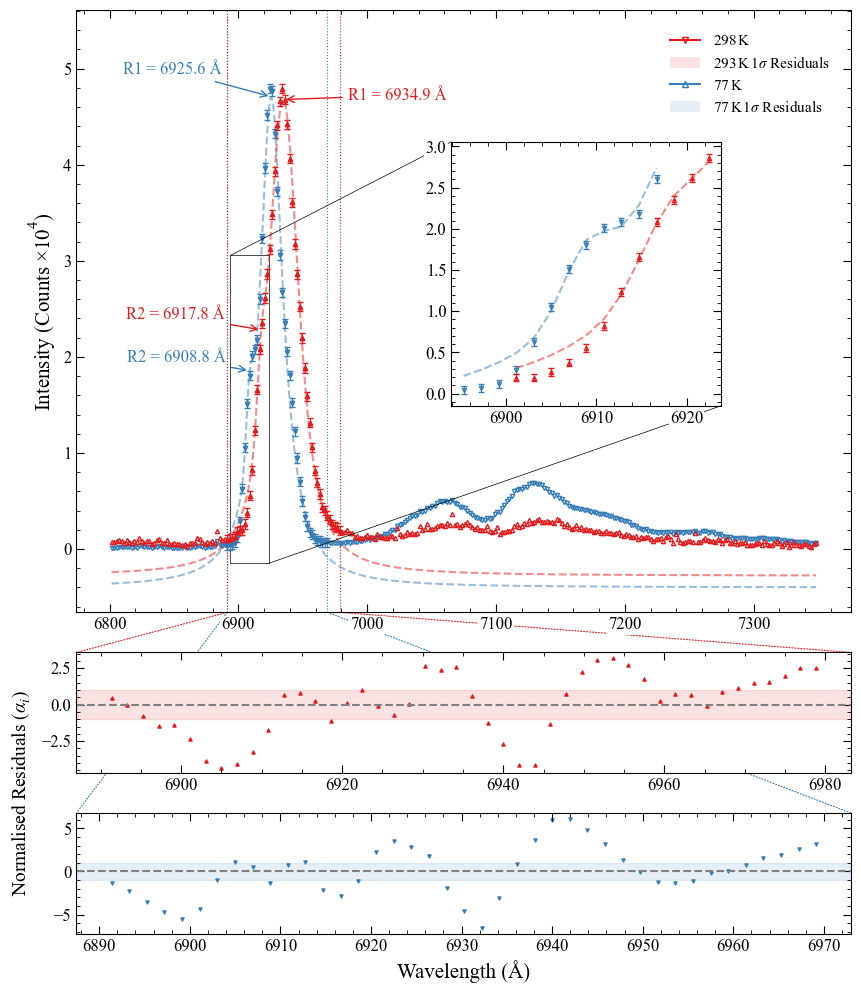

In [44]:
fig = plt.figure(figsize=(10, 12))

gs = fig.add_gridspec(
    5, 1,
    height_ratios=[6, 0.4, 1.2, 0.4, 1.2],  # spacer rows included
    hspace=0.0
)

ax_main = fig.add_subplot(gs[0])
ax_res_77 = fig.add_subplot(gs[4])
ax_res_298 = fig.add_subplot(gs[2])

##############
# Main Spectra
##############

for xdata, ydata, yerror, pop, marker, colour, xbroad, ybroad in zip(
        [x_77_ocean, x_298_ocean], [y_77_ocean, y_298_ocean], y_err_ocean, pop_list, marker_list,
        colour_list, [x_77_broad_ocean, x_298_broad_ocean], [y_77_broad_ocean, y_298_broad_ocean]
):
    ax_main.errorbar(xdata * x_scalefactor_ocean, ydata * y_scalefactor_ocean, yerr=yerror * y_scalefactor_ocean,
                     color=colour, marker=marker, linestyle="none", markerfacecolor="none", capsize=2, markersize=3,
                     elinewidth=0.8)

    ax_main.plot(wavelength_range_ocean * x_scalefactor_ocean, voigt_model_double(wavelength_range_ocean, *pop) * y_scalefactor_ocean,
                 color=colour, linestyle="--", alpha=0.5)

    ax_main.errorbar(xbroad * x_scalefactor_ocean, ybroad * y_scalefactor_ocean, yerr=np.zeros_like(ybroad),
                     color=colour, marker=marker, linestyle="none", markerfacecolor="none", capsize=0, markersize=3,
                     elinewidth=0.8)

    ax_main.axvline(xdata[0] * x_scalefactor_ocean, color=colour, linestyle=":", linewidth=0.8)
    ax_main.axvline(xdata[-1] * x_scalefactor_ocean, color=colour, linestyle=":", linewidth=0.8)

# Get current limits
ymin, ymax = ax_main.get_ylim()

# Extend the top by, say, 10%
ax_main.set_ylim(ymin, ymax * 1.1)

ax_main.set_ylabel(r"Intensity (Counts $\times 10^{4}$)")

ax_main.legend(
    handles=legend_elements_ocean,
    loc="upper left",
    bbox_to_anchor=(0.75, 0.98),
    borderpad=0.3,
    facecolor="white",
    edgecolor="white",
    framealpha=1
)

##########################
# Main Spectra Annotations
##########################

# Annotate on ax_main
ax_main.annotate(
    rf"R1 = {R1_293_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R1_293_ocean * x_scalefactor_ocean, amp_R1_293_ocean * y_scalefactor_ocean),
    xytext=((R1_293_ocean + 5) * x_scalefactor_ocean, amp_R1_293_ocean * 1. * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_293_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R2_293_ocean * x_scalefactor_ocean, amp_R2_293_ocean * y_scalefactor_ocean),
    xytext=((R2_293_ocean - 10.5) * x_scalefactor_ocean, amp_R2_293_ocean * 1.05 * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R1 = {R1_77_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R1_77_ocean * x_scalefactor_ocean, amp_R1_77_ocean * y_scalefactor_ocean),
    xytext=((R1_77_ocean - 11.5) * x_scalefactor_ocean, amp_R1_77_ocean * 1.05 * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_77_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R2_77_ocean * x_scalefactor_ocean, amp_R2_77_ocean * y_scalefactor_ocean),
    xytext=((R2_77_ocean - 9.5) * x_scalefactor_ocean, amp_R2_77_ocean * 1.05 * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

#######
# inset
#######
a, b, c, d = 51, 63, 48, 60
ax_inset = fig.add_axes([0.5, 0.55, 0.27, 0.22])
mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="black", lw=0.5)
ax_inset.errorbar(x_77_broad_ocean[c:d] * x_scalefactor_ocean, y_77_broad_ocean[c:d] * y_scalefactor_ocean,
                  yerr=y_err_ocean[0] * y_scalefactor_ocean,
                  color=colour_list[0], capsize=2, fmt=marker_list[0], linestyle="none", markerfacecolor="none",
                  markersize=3, elinewidth=0.8)
ax_inset.plot(x_77_broad_ocean[c:d] * x_scalefactor_ocean,
              voigt_model_double(x_77_broad_ocean[c:d], *pop_77_ocean) * y_scalefactor_ocean,
              color=colour_list[0], linestyle="--", alpha=0.5)

ax_inset.errorbar(x_298_broad_ocean[a:b] * x_scalefactor_ocean, y_298_broad_ocean[a:b] * y_scalefactor_ocean,
                  yerr=y_err_ocean[1] * y_scalefactor_ocean,
                  color=colour_list[1], capsize=2, fmt=marker_list[1], linestyle="none", markerfacecolor="none",
                  markersize=3, elinewidth=0.8)
ax_inset.plot(x_298_broad_ocean[a:b] * x_scalefactor_ocean,
              voigt_model_double(x_298_broad_ocean[a:b], *pop_298_ocean) * y_scalefactor_ocean,
              color=colour_list[1], linestyle="--", alpha=0.5)

###########
# Residuals
###########

for ax, xdata, residual, colour, marker in zip(
        [ax_res_77, ax_res_298], [x_77_ocean, x_298_ocean], residual_list, colour_list, marker_list
):
    ax.scatter(xdata * x_scalefactor_ocean, residual,
               color=colour, marker=marker, s=5)
    ax.axhspan(-1, 1, color=colour, alpha=0.12)
    ax.axhline(0, color="grey", linestyle="--")

# Get positions of residual axes
pos1 = ax_res_77.get_position()
pos2 = ax_res_298.get_position()

# Midpoint of the gap between them
y_mid = (pos1.y0 + pos2.y1) / 2

# Shared residual label
fig.text(
    0.07, y_mid,
    r"Normalised Residuals ($\alpha_i$)",
    rotation=90,
    va='center',
    ha='center'
)

ax_res_77.set_xlabel("Wavelength (Å)")

#########
# Styling
#########

for ax in [ax_main, ax_res_77, ax_res_298, ax_inset]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

# Bottom of main axis in data coordinates
y_bottom = ax_main.get_ylim()[0]

# Example: connect left mask (293K) to top-left of residual 293 plot
con1 = ConnectionPatch(
    xyA=(x_77_ocean[0] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res_77.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con1)

# Connect right mask (293K) to top-right of residual 293 plot
con2 = ConnectionPatch(
    xyA=(x_77_ocean[-1] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res_77.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con2)

# Same idea for 77K residuals
con3 = ConnectionPatch(
    xyA=(x_298_ocean[0] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res_298.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con3)

con4 = ConnectionPatch(
    xyA=(x_298_ocean[-1] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res_298.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con4)

plt.savefig(
    pc_savepath_ocean_emission_spectra,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# Combined Plot

In [53]:
pc_savepath_combined_emission_spectra = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\combined_spectra.png"

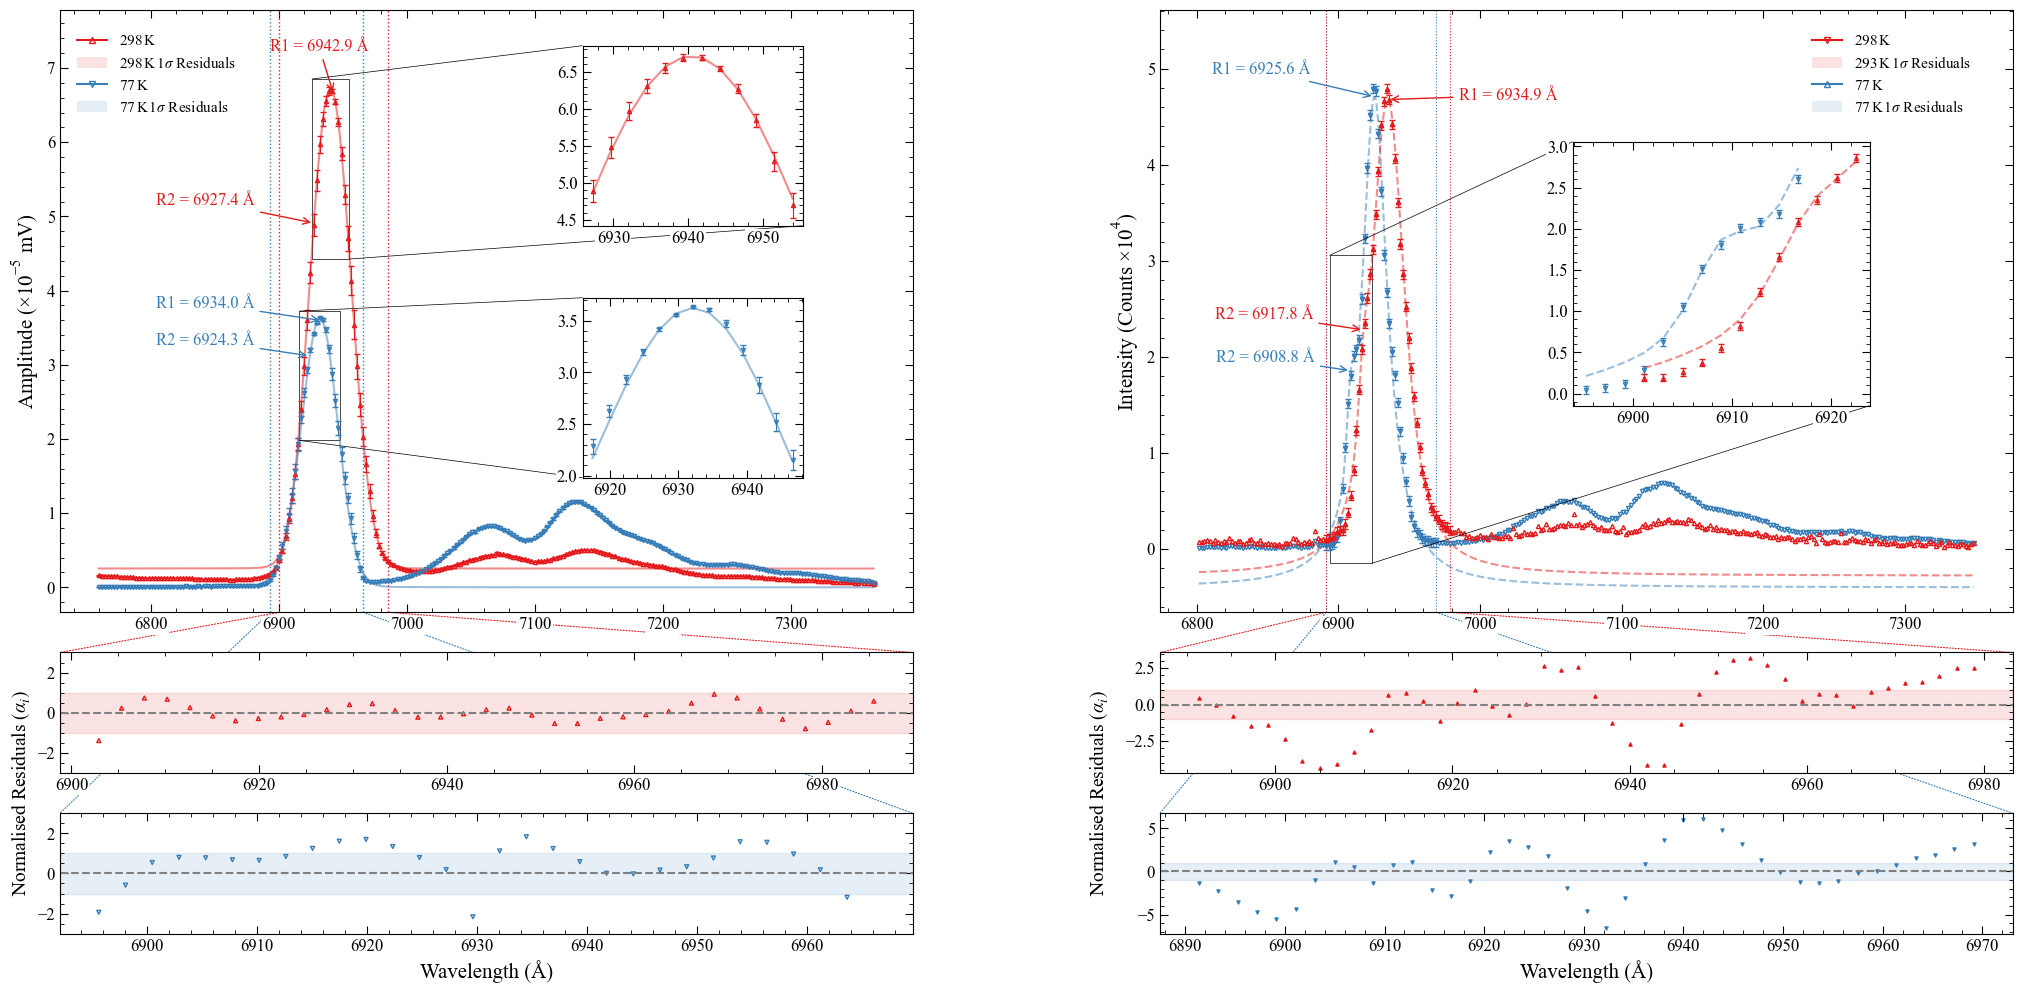

In [61]:
fig = plt.figure(figsize = (22,12))
outer_gs = fig.add_gridspec(1, 2, wspace=0.15)


##########################
# LEFT: Monochromator Plot
##########################

subfig1 = fig.add_subfigure(outer_gs[0])

# Add extra spacing and larger residual panels
gs1 = subfig1.add_gridspec(
    5, 1,
    height_ratios=[6, 0.4, 1.2, 0.4, 1.2],  # spacer rows included
    hspace=0.0
)

ax_main = subfig1.add_subplot(gs1[0])
ax_res1 = subfig1.add_subplot(gs1[2])
ax_res2 = subfig1.add_subplot(gs1[4])

# =====================
# Main spectrum
# =====================

scale_factor = 1e5
x_scale_factor = 10

marker_293 = "^"
marker_77 = "v"

data293 = ax_main.errorbar(
    x_298_mono * x_scale_factor, y_298_mono * scale_factor, yerr=err_298_mono * scale_factor,
    color=red_cb, capsize=2, fmt=marker_293, linestyle="none",
    markerfacecolor="none", markersize=3, elinewidth=0.8
)

data77 = ax_main.errorbar(
    x_77_mono * x_scale_factor, y_77_mono * scale_factor, yerr=err_77_mono * scale_factor,
    color=blue_cb, capsize=2, fmt=marker_77, linestyle="none",
    markerfacecolor="none", markersize=3, elinewidth=0.8
)

fit293, = ax_main.plot(
    wavelength_range_mono * x_scale_factor,
    voigt_model_double(wavelength_range_mono, *pop_298_mono) * scale_factor,
    color=red_cb, linestyle="-", alpha=0.5
)

fit77, = ax_main.plot(
    wavelength_range_mono * x_scale_factor,
    voigt_model_double(wavelength_range_mono, *pop_77_mono) * scale_factor,
    color=blue_cb, linestyle="-", alpha=0.5
)

# Get current limits
ymin, ymax = ax_main.get_ylim()

# Extend the top by, say, 10%
ax_main.set_ylim(ymin, ymax * 1.1)

# Mask boundaries
ax_main.axvline(x_298_mono[left_298_mono] * x_scale_factor, color=red_cb, linestyle=":", linewidth=1,
                label="293K Mask")
ax_main.axvline(x_298_mono[right_298_mono] * x_scale_factor, color=red_cb, linestyle=":", linewidth=1)
ax_main.axvline(x_77_mono[left_77_mono] * x_scale_factor, color=blue_cb, linestyle=":", linewidth=1,
                label="77K Mask")
ax_main.axvline(x_77_mono[right_77_mono] * x_scale_factor, color=blue_cb, linestyle=":", linewidth=1)

ax_main.set_ylabel(r"Amplitude ($\times 10^{-5}$ mV)")

ax_main.legend(
    handles=legend_elements_mono,
    loc="upper left",
    bbox_to_anchor=(0.005, 0.98),
    borderpad=0.3,
    frameon=False
)

# Annotate on ax_main
ax_main.annotate(
    rf"R1 = {R1_293_mono * x_scale_factor:.1f} Å",
    xy=(R1_293_mono * x_scale_factor, amp_R1_293_mono * scale_factor),
    xytext=((R1_293_mono - 5) * x_scale_factor, amp_R1_293_mono * 1.09 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_293_mono * x_scale_factor:.1f} Å",
    xy=(R2_293_mono * x_scale_factor, amp_R2_293_mono * scale_factor),
    xytext=((R2_293_mono - 12.3) * x_scale_factor, amp_R2_293_mono * 1.05 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R1 = {R1_77_mono * x_scale_factor:.1f} Å",
    xy=(R1_77_mono * x_scale_factor, amp_R1_77_mono * scale_factor),
    xytext=((R1_77_mono - 13) * x_scale_factor, amp_R1_77_mono * 1.05 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_77_mono * x_scale_factor:.1f} Å",
    xy=(R2_77_mono * x_scale_factor, amp_R2_77_mono * scale_factor),
    xytext=((R2_77_mono - 12) * x_scale_factor, amp_R2_77_mono * 1.05 * scale_factor),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

# =====================
# Residuals 293K
# =====================
ax_res1.scatter(
    x_298_mono[left_298_mono:right_298_mono] * x_scale_factor,
    residuals_298_mono,
    color=red_cb, s=8, facecolor="none", marker=marker_293
)

ax_res1.axhspan(-1, 1, color=red_cb, alpha=0.12)
ax_res1.axhline(0, color="grey", linestyle="--")
ax_res1.set_ylim(-3, 3)

# =====================
# Residuals 77K
# =====================
ax_res2.scatter(
    x_77_mono[left_77_mono:right_77_mono] * x_scale_factor,
    residuals_77_mono,
    color=blue_cb, s=8, facecolor="none", marker=marker_77
)

ax_res2.axhspan(-1, 1, color=blue_cb, alpha=0.12)
ax_res2.axhline(0, color="grey", linestyle="--")
ax_res2.set_ylim(-3, 3)

ax_res2.set_xlabel("Wavelength (Å)")

# Get positions of residual axes
pos1 = ax_res1.get_position()
pos2 = ax_res2.get_position()

# Midpoint of the gap between them
y_mid = (pos1.y0 + pos2.y1) / 2

# Shared residual label
subfig1.text(
    0.09, y_mid,
    r"Normalised Residuals ($\alpha_i$)",
    rotation=90,
    va='center',
    ha='center'
)

ax_inset_293 = subfig1.add_axes([0.6, 0.7, 0.2, 0.15])
mark_inset(ax_main, ax_inset_293, loc1=2, loc2=4, fc="none", ec="black", lw=0.5)
ax_inset_293.errorbar(x_298_mono[left_298_mono + 13:right_298_mono - 10] * x_scale_factor,
                      y_298_mono[left_298_mono + 13:right_298_mono - 10] * scale_factor,
                      yerr=err_298_mono[left_298_mono + 13:right_298_mono - 10] * scale_factor,
                      color=red_cb, capsize=2, fmt=marker_293, linestyle="none", markerfacecolor="none", markersize=3,
                      elinewidth=0.8)
ax_inset_293.plot(x_298_mono[left_298_mono + 13:right_298_mono - 10] * x_scale_factor,
                  voigt_model_double(x_298_mono[left_298_mono + 13:right_298_mono - 10], *pop_298_mono) * scale_factor,
                  color=red_cb, linestyle="-", alpha=0.5)
ax_inset_293.set_yticks([4.5, 5, 5.5, 6, 6.5])

ax_inset_77 = subfig1.add_axes([0.6, 0.49, 0.2, 0.15])

c, d = 16, 6
mark_inset(ax_main, ax_inset_77, loc1=2, loc2=3, fc="none", ec="black", lw=0.5)
ax_inset_77.errorbar(x_77_mono[left_298_mono + c:right_298_mono - d] * x_scale_factor,
                     y_77_mono[left_298_mono + c:right_298_mono - d] * scale_factor,
                     yerr=err_77_mono[left_298_mono + c:right_298_mono - d] * scale_factor,
                     color=blue_cb, capsize=2, fmt=marker_77, linestyle="none", markerfacecolor="none", markersize=3,
                     elinewidth=0.8)
ax_inset_77.plot(x_77_mono[left_298_mono + c:right_298_mono - d] * x_scale_factor,
                 voigt_model_double(x_77_mono[left_298_mono + c:right_298_mono - d], *pop_77_mono) * scale_factor,
                 color=blue_cb, linestyle="-", alpha=0.5)

# Bottom of main axis in data coordinates
y_bottom = ax_main.get_ylim()[0]

# Example: connect left mask (293K) to top-left of residual 293 plot
con1 = ConnectionPatch(
    xyA=(x_298_mono[right_298_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res1.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig1.add_artist(con1)

# Connect right mask (293K) to top-right of residual 293 plot
con2 = ConnectionPatch(
    xyA=(x_298_mono[left_298_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res1.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig1.add_artist(con2)

# Same idea for 77K residuals
con3 = ConnectionPatch(
    xyA=(x_77_mono[right_77_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res2.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig1.add_artist(con3)

con4 = ConnectionPatch(
    xyA=(x_77_mono[left_77_mono] * x_scale_factor, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res2.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig1.add_artist(con4)

# Styling
for ax in [ax_main, ax_res1, ax_res2, ax_inset_293, ax_inset_77]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

for ax in [ax_main, ax_res1, ax_res2, ax_inset_293, ax_inset_77]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

subfig2 = fig.add_subfigure(outer_gs[1])

gs2 = subfig2.add_gridspec(
    5, 1,
    height_ratios=[6, 0.4, 1.2, 0.4, 1.2],  # spacer rows included
    hspace=0.0
)

ax_main = subfig2.add_subplot(gs2[0])
ax_res_77 = subfig2.add_subplot(gs2[4])
ax_res_298 = subfig2.add_subplot(gs2[2])

##############
# Main Spectra
##############

for xdata, ydata, yerror, pop, marker, colour, xbroad, ybroad in zip(
        [x_77_ocean, x_298_ocean], [y_77_ocean, y_298_ocean], y_err_ocean, pop_list, marker_list,
        colour_list, [x_77_broad_ocean, x_298_broad_ocean], [y_77_broad_ocean, y_298_broad_ocean]
):
    ax_main.errorbar(xdata * x_scalefactor_ocean, ydata * y_scalefactor_ocean, yerr=yerror * y_scalefactor_ocean,
                     color=colour, marker=marker, linestyle="none", markerfacecolor="none", capsize=2, markersize=3,
                     elinewidth=0.8)

    ax_main.plot(wavelength_range_ocean * x_scalefactor_ocean,
                 voigt_model_double(wavelength_range_ocean, *pop) * y_scalefactor_ocean,
                 color=colour, linestyle="--", alpha=0.5)

    ax_main.errorbar(xbroad * x_scalefactor_ocean, ybroad * y_scalefactor_ocean, yerr=np.zeros_like(ybroad),
                     color=colour, marker=marker, linestyle="none", markerfacecolor="none", capsize=0, markersize=3,
                     elinewidth=0.8)

    ax_main.axvline(xdata[0] * x_scalefactor_ocean, color=colour, linestyle=":", linewidth=0.8)
    ax_main.axvline(xdata[-1] * x_scalefactor_ocean, color=colour, linestyle=":", linewidth=0.8)

# Get current limits
ymin, ymax = ax_main.get_ylim()

# Extend the top by, say, 10%
ax_main.set_ylim(ymin, ymax * 1.1)

ax_main.set_ylabel(r"Intensity (Counts $\times 10^{4}$)")

ax_main.legend(
    handles=legend_elements_ocean,
    loc="upper left",
    bbox_to_anchor=(0.75, 0.98),
    borderpad=0.3,
    facecolor="white",
    edgecolor="white",
    framealpha=1
)

##########################
# Main Spectra Annotations
##########################

# Annotate on ax_main
ax_main.annotate(
    rf"R1 = {R1_293_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R1_293_ocean * x_scalefactor_ocean, amp_R1_293_ocean * y_scalefactor_ocean),
    xytext=((R1_293_ocean + 5) * x_scalefactor_ocean, amp_R1_293_ocean * 1. * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_293_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R2_293_ocean * x_scalefactor_ocean, amp_R2_293_ocean * y_scalefactor_ocean),
    xytext=((R2_293_ocean - 10.5) * x_scalefactor_ocean, amp_R2_293_ocean * 1.05 * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R1 = {R1_77_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R1_77_ocean * x_scalefactor_ocean, amp_R1_77_ocean * y_scalefactor_ocean),
    xytext=((R1_77_ocean - 11.5) * x_scalefactor_ocean, amp_R1_77_ocean * 1.05 * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_77_ocean * x_scalefactor_ocean:.1f} Å",
    xy=(R2_77_ocean * x_scalefactor_ocean, amp_R2_77_ocean * y_scalefactor_ocean),
    xytext=((R2_77_ocean - 9.5) * x_scalefactor_ocean, amp_R2_77_ocean * 1.05 * y_scalefactor_ocean),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

#######
# inset
#######
a, b, c, d = 51, 63, 48, 60
ax_inset = subfig2.add_axes([0.5, 0.55, 0.27, 0.22])
mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="black", lw=0.5)
ax_inset.errorbar(x_77_broad_ocean[c:d] * x_scalefactor_ocean, y_77_broad_ocean[c:d] * y_scalefactor_ocean,
                  yerr=y_err_ocean[0] * y_scalefactor_ocean,
                  color=colour_list[0], capsize=2, fmt=marker_list[0], linestyle="none", markerfacecolor="none",
                  markersize=3, elinewidth=0.8)
ax_inset.plot(x_77_broad_ocean[c:d] * x_scalefactor_ocean,
              voigt_model_double(x_77_broad_ocean[c:d], *pop_77_ocean) * y_scalefactor_ocean,
              color=colour_list[0], linestyle="--", alpha=0.5)

ax_inset.errorbar(x_298_broad_ocean[a:b] * x_scalefactor_ocean, y_298_broad_ocean[a:b] * y_scalefactor_ocean,
                  yerr=y_err_ocean[1] * y_scalefactor_ocean,
                  color=colour_list[1], capsize=2, fmt=marker_list[1], linestyle="none", markerfacecolor="none",
                  markersize=3, elinewidth=0.8)
ax_inset.plot(x_298_broad_ocean[a:b] * x_scalefactor_ocean,
              voigt_model_double(x_298_broad_ocean[a:b], *pop_298_ocean) * y_scalefactor_ocean,
              color=colour_list[1], linestyle="--", alpha=0.5)

###########
# Residuals
###########

for ax, xdata, residual, colour, marker in zip(
        [ax_res_77, ax_res_298], [x_77_ocean, x_298_ocean], residual_list, colour_list, marker_list
):
    ax.scatter(xdata * x_scalefactor_ocean, residual,
               color=colour, marker=marker, s=5)
    ax.axhspan(-1, 1, color=colour, alpha=0.12)
    ax.axhline(0, color="grey", linestyle="--")

# Get positions of residual axes
pos1 = ax_res_77.get_position()
pos2 = ax_res_298.get_position()

# Midpoint of the gap between them
y_mid = (pos1.y0 + pos2.y1) / 2

# Shared residual label
subfig2.text(
    0.07, y_mid,
    r"Normalised Residuals ($\alpha_i$)",
    rotation=90,
    va='center',
    ha='center'
)

ax_res_77.set_xlabel("Wavelength (Å)")

#########
# Styling
#########

for ax in [ax_main, ax_res_77, ax_res_298, ax_inset]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

# Bottom of main axis in data coordinates
y_bottom = ax_main.get_ylim()[0]

# Example: connect left mask (293K) to top-left of residual 293 plot
con1 = ConnectionPatch(
    xyA=(x_77_ocean[0] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res_77.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig2.add_artist(con1)

# Connect right mask (293K) to top-right of residual 293 plot
con2 = ConnectionPatch(
    xyA=(x_77_ocean[-1] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res_77.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig2.add_artist(con2)

# Same idea for 77K residuals
con3 = ConnectionPatch(
    xyA=(x_298_ocean[0] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res_298.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig2.add_artist(con3)

con4 = ConnectionPatch(
    xyA=(x_298_ocean[-1] * x_scalefactor_ocean, y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res_298.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
subfig2.add_artist(con4)

plt.savefig(
    pc_savepath_combined_emission_spectra,
    dpi=200,
    bbox_inches="tight"
)

plt.show()